# Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

## Bước 1: Cài đặt các thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import graphviz
from sklearn.model_selection import train_test_split
from sklearn import tree

%matplotlib inline
mpl.rcParams['figure.dpi'] = 400  # Độ phân giải cao


## Bước 2: Nạp dữ liệu và loại bỏ các cột không cần thiết

In [2]:
df = pd.read_csv("default_of_credit_card_clients.csv")

features_response = df.columns.tolist()

# Danh sách các cột không dùng
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',
                   'PAY_4', 'PAY_5', 'PAY_6',
                   'EDUCATION_CAT', 'graduate school',
                   'high school', 'none',
                   'others', 'university']

features_response = [item for item in features_response if item not in items_to_remove]
print(features_response)


['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


## Bước 3: Chia dữ liệu Train/Test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features_response[:-1]].values,
    df['default payment next month'].values,
    test_size=0.2,
    random_state=24
)


## Bước 4: Xây dựng mô hình cây quyết định

In [4]:
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2)

## Bước 5: Vẽ cây quyết định

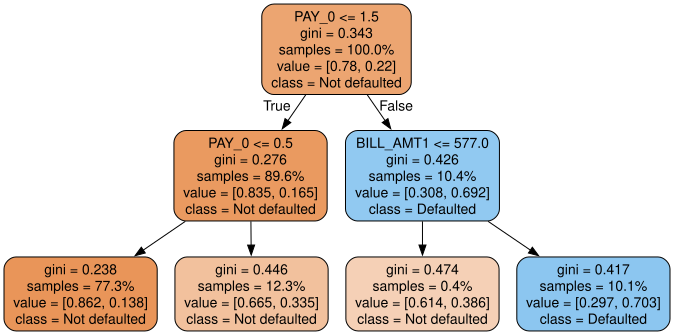

In [5]:
dot_data = tree.export_graphviz(dt,
out_file=None,
filled=True,
rounded=True,
feature_names=\
features_response[:-1],
proportion=True,
class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph